# Estilometría de Ajedrez 2 - CNN Siamesa con Bloques
---

In [14]:
# SETUP
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import cv2
import random
import tensorflow as tf
from pathlib import Path
from keras import layers, losses, optimizers, metrics, Model
from keras.applications import resnet
from collections import defaultdict

print("TF version:", tf.__version__)

# Configurar GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU configurada: {len(gpus)} dispositivo(s)")

# Parámetros
IMG_SHAPE = (192, 192)
BATCH_SIZE = 32
EPOCHS = 50
SEED = 314
NUM_BLOCKS = 3  # 3 bloques por partida

# Reproducibilidad
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

TF version: 2.20.0
GPU configurada: 1 dispositivo(s)


## 1. Descubrir Eventos Disponibles

In [9]:
# pipeline
import importlib
sys.path.insert(0, str(Path('../').resolve()))
import v002_pipeline_stylometry_blocks
importlib.reload(v002_pipeline_stylometry_blocks)
from v002_pipeline_stylometry_blocks import discover_available_events

pgn_file = Path('../dataset/generated/lichess_db.pgn')

print("Escaneando PGN para descubrir eventos...\n")
events = discover_available_events(pgn_file, max_games=100000)

print("\n✓ Descubrimiento completado")
print(f"Total de eventos únicos: {len(events)}")

Escaneando PGN para descubrir eventos...


DESCUBRIMIENTO PARALELO DE EVENTOS (Optimizado RAM)
Archivo: ../dataset/generated/lichess_db.pgn
Workers: 8 (cores disponibles: 72)
RAM disponible: 113.0 GB
Límite: 100,000 partidas

Fase 1: Calculando límites de chunks...
  ✓ 8 chunks creados
  ✓ Tamaño total: 202943.1 MB
  ✓ ~25367.9 MB por chunk

Fase 2: Procesando chunks en paralelo...
(Usando streaming para minimizar uso de RAM)


Fase 3: Fusionando resultados...
  ✓ 100,008 partidas procesadas
  ✓ 541 eventos únicos encontrados


TOP 20 EVENTOS MÁS COMUNES

#    Evento                                     Partidas  Jugadores
----------------------------------------------------------------------
1    Rated Blitz game                             41,888     64,453
2    Rated Bullet game                            33,567     35,422
3    Rated Rapid game                             13,869     24,043
4    Rated Classical game                            489        933
5    Rated UltraBullet game

## 2. Seleccionar Evento y Ejecutar Pipeline

In [10]:
# Seleccionar evento
SELECTED_EVENT = "Rated Blitz game"

if SELECTED_EVENT in events:
    event_stats = events[SELECTED_EVENT]
    print(f"\nEvento seleccionado: {SELECTED_EVENT}")
    print(f"  Partidas disponibles: {event_stats['games']:,}")
    print(f"  Jugadores únicos: {event_stats['unique_players']:,}")


Evento seleccionado: Rated Blitz game
  Partidas disponibles: 41,888
  Jugadores únicos: 64,453


In [30]:
from v002_pipeline_stylometry_blocks import ChessStylometryPipelineV002

pipeline = ChessStylometryPipelineV002(
    massive_pgn=pgn_file,
    output_base=Path('output'),
    event_type=SELECTED_EVENT,
    num_players=20,              # Top 20 jugadores
    games_per_player=30,          # 30 partidas por jugador
    min_threshold=0.7,            # Mínimo 70% de partidas
    move_start=15,                # Movimiento inicial
    move_end=30,                  # Movimiento final (15 movimientos)
    num_blocks=3,                 # Dividir en 3 bloques de 5 movimientos
    compression_factor=1,         # Sin compresión (192x192)
    use_relative_time=True        # Tiempos relativos en heatmaps
)

stats = pipeline.run()


######################################################################
# PIPELINE DE ESTILOMETRÍA V002 - BLOQUES
######################################################################

Evento: Rated Blitz game
Bloques configurados: 3
  - block_01: movimientos 29-38
  - block_02: movimientos 39-48
  - block_03: movimientos 49-58
Output: output/events/Rated_Blitz_game

✓ JUGADORES YA EXTRAÍDOS (SALTANDO FASE 1)

Encontrados 98 jugadores en: output/events/Rated_Blitz_game/player_pgns
Usando datos existentes...

  ✓ joseluisac
  ✓ queensgambithater
  ✓ Kalcole97
  ✓ siriconsuegra
  ✓ Mohammedkhalid88
  ✓ BhaweshSharma
  ✓ elkadi74
  ✓ Orasion
  ✓ Ashikkis
  ✓ adriananas
  ✓ Mieldepalma
  ✓ Manu97190
  ✓ Rook2025
  ✓ jazzmine
  ✓ LocustPizzaman
  ✓ nedstranger
  ✓ dugyaafel
  ✓ abnormal adult 57
  ✓ sciolistten
  ✓ SnakeEyesBishopPair2
  ✓ gabibo
  ✓ jretje
  ✓ pustilnic
  ✓ assom2
  ✓ Suray22
  ✓ letboy69
  ✓ BasmacH45
  ✓ Leonamantedelajedrez
  ✓ CHAMP 68
  ✓ Sexy Killer
  ✓ jun1845
  ✓ 

## 3. Visualizar Resultados (Bloques)

In [31]:
# Visualizar imágenes de bloques de un jugador
event_safe = SELECTED_EVENT.replace(" ", "_").replace("/", "_")
event_dir = Path(f'./output/events/{event_safe}')

# Listar jugadores disponibles
board_dir = event_dir / 'board_images'
players = [d.name for d in board_dir.iterdir() if d.is_dir()]

print(f"Jugadores disponibles ({len(players)}):")
for i, player in enumerate(players[:10], 1):
    print(f"  {i}. {player.replace('_', ' ')}")

if len(players) > 10:
    print(f"  ... y {len(players)-10} más")

Jugadores disponibles (98):
  1. CHESSmagicians
  2. chands18
  3. Ostrazzo 78
  4. gmkhal300od
  5. assom2
  6. Mininina
  7. Ben-gunn
  8. TonisImage
  9. gabibo
  10. cbazaz
  ... y 88 más



Visualizando partida 1 de CHESSmagicians


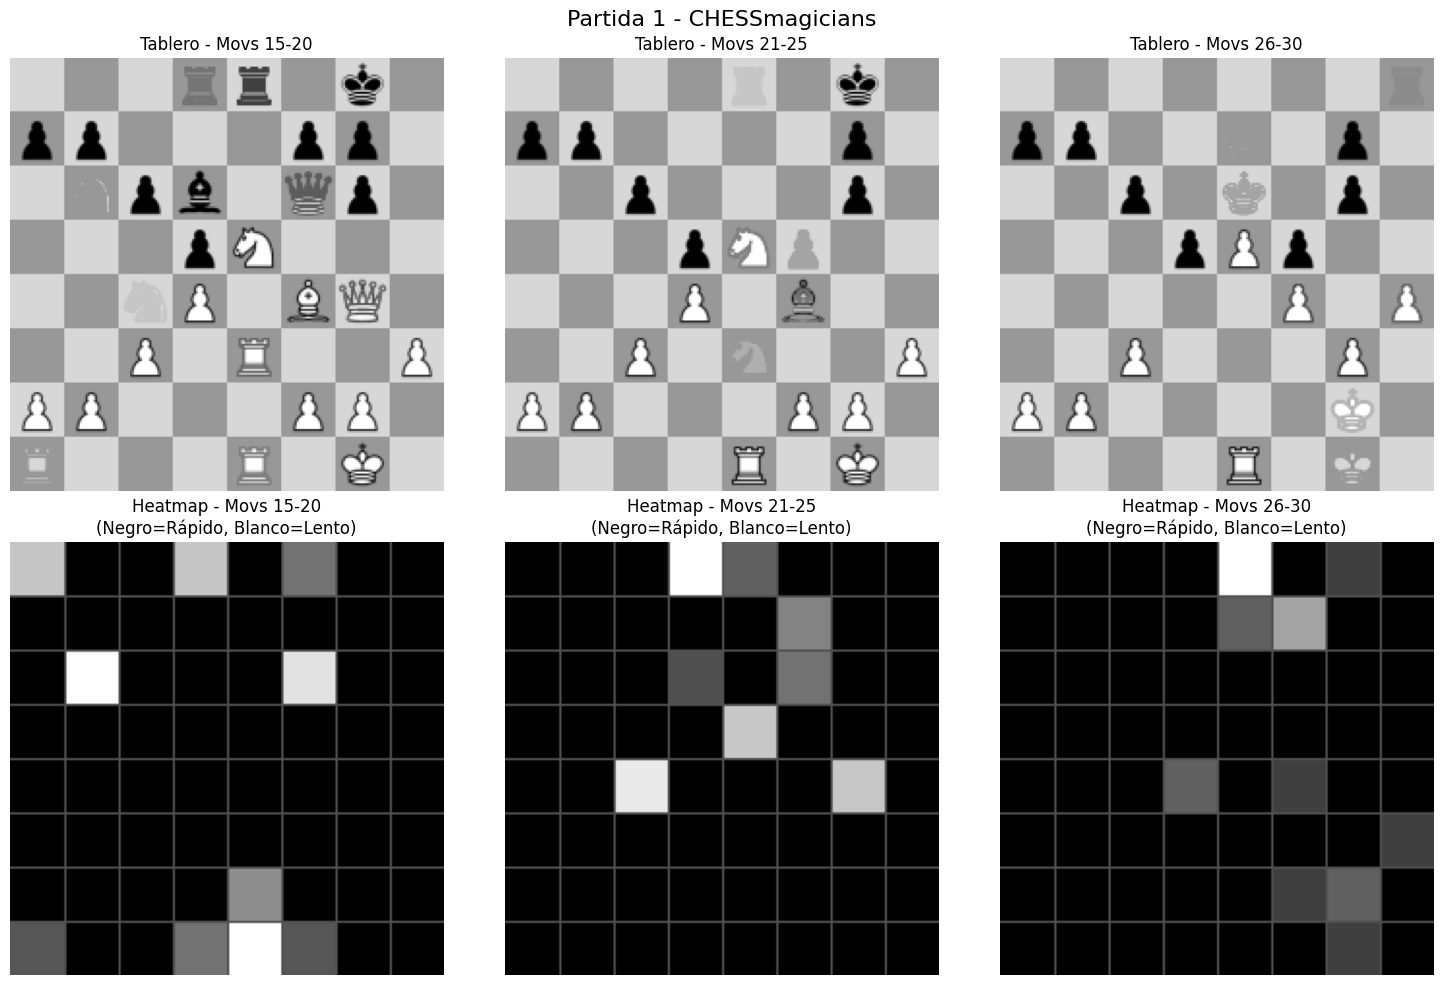


Interpretación de Heatmaps:
  - Negro/Oscuro: Decisiones rápidas (poco tiempo empleado)
  - Gris: Decisiones normales
  - Blanco/Claro: Decisiones lentas (mucho tiempo empleado)


In [41]:
# Mostrar bloques de una partida específica
player = players[0]  # Primer jugador
game_id = 1          # Primera partida

player_board_dir = board_dir / player
player_heat_dir = event_dir / 'heatmap_images' / player

print(f"\nVisualizando partida {game_id} de {player.replace('_', ' ')}")
print("="*70)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f"Partida {game_id} - {player.replace('_', ' ')}", fontsize=16)

blocks = ['block_01', 'block_02', 'block_03']
block_labels = ['Movs 15-20', 'Movs 21-25', 'Movs 26-30']

for idx, (block, label) in enumerate(zip(blocks, block_labels)):
    # Tablero
    board_file = player_board_dir / f"game_{game_id:04d}_{block}.png"
    if board_file.exists():
        board_img = cv2.imread(str(board_file))
        board_img = cv2.cvtColor(board_img, cv2.COLOR_BGR2RGB)
        axes[0, idx].imshow(board_img)
        axes[0, idx].set_title(f"Tablero - {label}")
        axes[0, idx].axis('off')
    
    # Heatmap
    heat_file = player_heat_dir / f"game_{game_id:04d}_{block}.png"
    if heat_file.exists():
        heat_img = cv2.imread(str(heat_file))
        heat_img = cv2.cvtColor(heat_img, cv2.COLOR_BGR2RGB)
        axes[1, idx].imshow(heat_img, cmap='gray')
        axes[1, idx].set_title(f"Heatmap - {label}\n(Negro=Rápido, Blanco=Lento)")
        axes[1, idx].axis('off')

plt.tight_layout()
plt.show()

print("\nInterpretación de Heatmaps:")
print("  - Negro/Oscuro: Decisiones rápidas (poco tiempo empleado)")
print("  - Gris: Decisiones normales")
print("  - Blanco/Claro: Decisiones lentas (mucho tiempo empleado)")

## A mejorar

Resulta que no se ven muchas de las jugadas, del mov 15-20 [Partida (https://lichess.org/997Q8NVt#30)] por ejemplo no se ve que realmente en la casilla de dama blanca (g4) había un alfil antes, no se renderiza

## 4. Preparar Dataset para Entrenamiento

Con los bloques, cada partida genera 3 pares de imágenes (tablero + heatmap).

In [42]:
def load_block_dataset(event_dir: Path, players: list, blocks: list):
    """
    Carga dataset con estructura de bloques.
    
    Cada muestra es un par (tablero, heatmap) para un bloque específico.
    """
    board_images = []
    heatmap_images = []
    labels = []
    
    player_to_id = {p: idx for idx, p in enumerate(players)}
    
    for player in players:
        player_board_dir = event_dir / 'board_images' / player
        player_heat_dir = event_dir / 'heatmap_images' / player
        
        if not player_board_dir.exists() or not player_heat_dir.exists():
            continue
        
        # Agrupar por partida
        game_ids = set()
        for f in player_board_dir.glob("game_*_block_*.png"):
            game_id = f.stem.split('_')[1]
            game_ids.add(game_id)
        
        for game_id in sorted(game_ids):
            for block in blocks:
                board_file = player_board_dir / f"game_{game_id}_{block}.png"
                heat_file = player_heat_dir / f"game_{game_id}_{block}.png"
                
                if board_file.exists() and heat_file.exists():
                    # Cargar y normalizar
                    board = cv2.imread(str(board_file))
                    board = cv2.cvtColor(board, cv2.COLOR_BGR2RGB)
                    board = cv2.resize(board, IMG_SHAPE) / 255.0
                    
                    heat = cv2.imread(str(heat_file), cv2.IMREAD_GRAYSCALE)
                    heat = cv2.resize(heat, IMG_SHAPE) / 255.0
                    heat = np.expand_dims(heat, axis=-1)  # Add channel dimension
                    
                    board_images.append(board)
                    heatmap_images.append(heat)
                    labels.append(player_to_id[player])
    
    return (
        np.array(board_images, dtype=np.float32),
        np.array(heatmap_images, dtype=np.float32),
        np.array(labels, dtype=np.int32)
    )

# Load dataset
print("Cargando dataset")
blocks = ['block_01', 'block_02', 'block_03']

board_imgs, heat_imgs, player_labels = load_block_dataset(event_dir, players, blocks)

print(f"\n Dataset cargado:")
print(f"  Tableros: {board_imgs.shape}")
print(f"  Heatmaps: {heat_imgs.shape}")
print(f"  Labels: {player_labels.shape}")
print(f"  Jugadores: {len(players)}")
print(f"  Muestras por jugador (promedio): {len(player_labels) // len(players):.1f}")

Cargando dataset

 Dataset cargado:
  Tableros: (4437, 192, 192, 3)
  Heatmaps: (4437, 192, 192, 1)
  Labels: (4437,)
  Jugadores: 98
  Muestras por jugador (promedio): 45.0


## 5. Construir Modelo Siamés con Dual Channel

Arquitectura:
- **Canal 1**: Tablero (RGB, 192x192x3)
- **Canal 2**: Heatmap Grayscale (192x192x1)
- Procesamiento separado con CNNs
- Fusión de features
- Clasificación de jugadores

In [34]:
def build_dual_channel_model(num_players: int, img_shape=(192, 192)):
    """
    Construye modelo con dos canales:
    - Canal RGB (tablero)
    - Canal Grayscale (heatmap)
    """
    # Input  tablero
    board_input = layers.Input(shape=(*img_shape, 3), name='board_input')
    
    # Input  heatmap
    heat_input = layers.Input(shape=(*img_shape, 1), name='heat_input')
    
    # Encoder para tablero
    x_board = layers.Conv2D(32, 3, activation='relu', padding='same')(board_input)
    x_board = layers.MaxPooling2D(2)(x_board)
    x_board = layers.Conv2D(64, 3, activation='relu', padding='same')(x_board)
    x_board = layers.MaxPooling2D(2)(x_board)
    x_board = layers.Conv2D(128, 3, activation='relu', padding='same')(x_board)
    x_board = layers.GlobalAveragePooling2D()(x_board)
    
    # Encoder para heatmap
    x_heat = layers.Conv2D(32, 3, activation='relu', padding='same')(heat_input)
    x_heat = layers.MaxPooling2D(2)(x_heat)
    x_heat = layers.Conv2D(64, 3, activation='relu', padding='same')(x_heat)
    x_heat = layers.MaxPooling2D(2)(x_heat)
    x_heat = layers.Conv2D(128, 3, activation='relu', padding='same')(x_heat)
    x_heat = layers.GlobalAveragePooling2D()(x_heat)
    
    # Fusionar features
    merged = layers.concatenate([x_board, x_heat])
    
    # Clasificador
    x = layers.Dense(256, activation='relu')(merged)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(num_players, activation='softmax')(x)
    
    model = Model(inputs=[board_input, heat_input], outputs=output)
    
    return model

# Construir modelo
model = build_dual_channel_model(num_players=len(players))

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

print("\n✓ Modelo construido:")
model.summary()

I0000 00:00:1764344098.863622  133132 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22502 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:02:00.0, compute capability: 8.6



✓ Modelo construido:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ board_input         │ (None, 192, 192,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ heat_input          │ (None, 192, 192,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 192, 192,  │        896 │ board_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 192, 192,  │        320 │ heat_input[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 96, 96,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 96, 96,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 96, 96,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 96, 96,    │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 48, 48,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 48, 48,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 48, 48,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 48, 48,    │     73,856 │ max_pooling2d_3[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ conv2d_2[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ conv2d_5[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     65,792 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 297,250 (1.13 MB)

 Trainable params: 297,250 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Entrenar Modelo

In [35]:
# Split train/validation
from sklearn.model_selection import train_test_split

X_board_train, X_board_val, X_heat_train, X_heat_val, y_train, y_val = train_test_split(
    board_imgs, heat_imgs, player_labels,
    test_size=0.2,
    random_state=SEED,
    stratify=player_labels
)

print("Dataset splits:")
print(f"  Train: {len(X_board_train)} muestras")
print(f"  Validation: {len(X_board_val)} muestras")

Dataset splits:
  Train: 3549 muestras
  Validation: 888 muestras


In [36]:
# Entrenar
history = model.fit(
    [X_board_train, X_heat_train],
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=([X_board_val, X_heat_val], y_val),
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3
        )
    ]
)

2025-11-28 15:35:38.596565: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 1569964032 exceeds 10% of free system memory.
2025-11-28 15:35:40.532744: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 1569964032 exceeds 10% of free system memory.


Epoch 1/50


2025-11-28 15:35:45.076935: I external/local_xla/xla/service/service.cc:163] XLA service 0x7b44b00522a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-28 15:35:45.077004: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA RTX A5000, Compute Capability 8.6
2025-11-28 15:35:45.391479: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-28 15:35:46.355792: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2025-11-28 15:35:46.751784: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-28 15:35:46.751831: I external

  5/111 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.0061 - loss: 4.5889

I0000 00:00:1764344160.457115  226913 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


109/111 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.0092 - loss: 4.5770

2025-11-28 15:36:04.344875: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-28 15:36:04.344916: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-28 15:36:04.344936: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-28 15:36:04.344956: I external/l

111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.0093 - loss: 4.5769

2025-11-28 15:36:13.854989: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-28 15:36:13.855036: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-28 15:36:14.572354: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_168', 8 bytes spill stores, 8 bytes spill loads

2025-11-28 15:36:15.023509: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Re

111/111 ━━━━━━━━━━━━━━━━━━━━ 38s 181ms/step - accuracy: 0.0101 - loss: 4.5714 - val_accuracy: 0.0146 - val_loss: 4.5361 - learning_rate: 0.0010
Epoch 2/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.0138 - loss: 4.5455 - val_accuracy: 0.0180 - val_loss: 4.5270 - learning_rate: 0.0010
Epoch 3/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.0158 - loss: 4.5333 - val_accuracy: 0.0169 - val_loss: 4.5175 - learning_rate: 0.0010
Epoch 4/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.0169 - loss: 4.5186 - val_accuracy: 0.0169 - val_loss: 4.5088 - learning_rate: 0.0010
Epoch 5/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.0147 - loss: 4.5039 - val_accuracy: 0.0214 - val_loss: 4.4836 - learning_rate: 0.0010
Epoch 6/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.0189 - loss: 4.4748 - val_accuracy: 0.0349 - val_loss: 4.4247 - learning_rate: 0.0010
Epoch 7/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.0262 - loss: 4.3650 - va

## 7. Evaluar y Visualizar Resultados

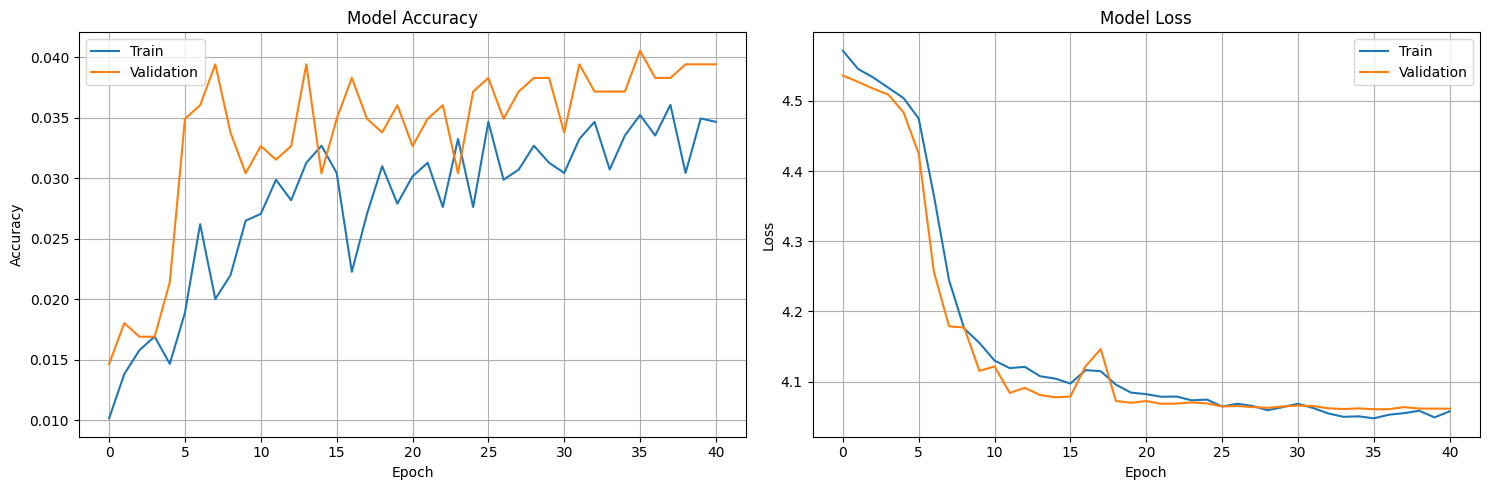


✓ Resultados finales:
  Validation Accuracy: 4.05%
  Validation Loss: 4.0605


In [38]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Final metrics
val_loss, val_acc = model.evaluate([X_board_val, X_heat_val], y_val, verbose=0)
print(f"\n✓ Resultados finales:")
print(f"  Validation Accuracy: {val_acc*100:.2f}%")
print(f"  Validation Loss: {val_loss:.4f}")

In [39]:
# Guardar modelo
model_dir = Path('../models/v002')
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / f'v002_blocks_{SELECTED_EVENT.replace(" ", "_")}.keras'
model.save(model_path)

print(f"✓ Modelo guardado: {model_path}")

✓ Modelo guardado: ../models/v002/v002_blocks_Rated_Blitz_game.keras
